In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
df.shape

(31780, 31)

In [4]:
df.dtypes

,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [5]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,1
V8,1
V9,1


In [6]:
df.duplicated().sum()

np.int64(129)

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,31780.000000,31780.000000,31780.000000,31780.000000,31780.000000,31780.000000,31780.000000,31779.000000,31779.000000,31779.000000,...,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000,31779.000000
mean,22329.432410,-0.212640,0.104667,0.721370,0.211236,-0.209710,0.088247,-0.120162,0.031883,0.314021,...,-0.033146,-0.119157,-0.040436,0.008409,0.134365,0.022637,0.012911,0.003384,81.115001,0.003210
std,12184.540274,1.854714,1.547456,1.589832,1.420692,1.408421,1.314428,1.283076,1.264390,1.250651,...,0.778376,0.640252,0.539220,0.591869,0.435709,0.508922,0.390404,0.300394,223.154481,0.056564
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-9.617915,0.000000,0.000000
25%,10971.000000,-0.956800,-0.467657,0.257092,-0.702958,-0.807339,-0.651105,-0.597343,-0.159243,-0.482553,...,-0.242905,-0.541636,-0.177032,-0.326931,-0.128724,-0.333026,-0.063132,-0.007594,6.790000,0.000000
50%,27331.000000,-0.246371,0.135141,0.842625,0.198585,-0.243626,-0.167815,-0.071105,0.038210,0.196750,...,-0.087460,-0.094216,-0.050669,0.062628,0.173028,-0.059277,0.008684,0.020795,20.000000,0.000000
75%,32942.000000,1.164230,0.776101,1.468823,1.095675,0.308333,0.474682,0.441280,0.298470,1.063590,...,0.087763,0.289984,0.075411,0.398097,0.417497,0.301347,0.089173,0.076435,73.705000,0.000000
max,36513.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,5.678671,7879.420000,1.000000


In [8]:
df.drop_duplicates(inplace=True)

In [12]:
fraud_count = df['Class'].value_counts()
fraud_count

,count
Class,
0.0,31548
1.0,102


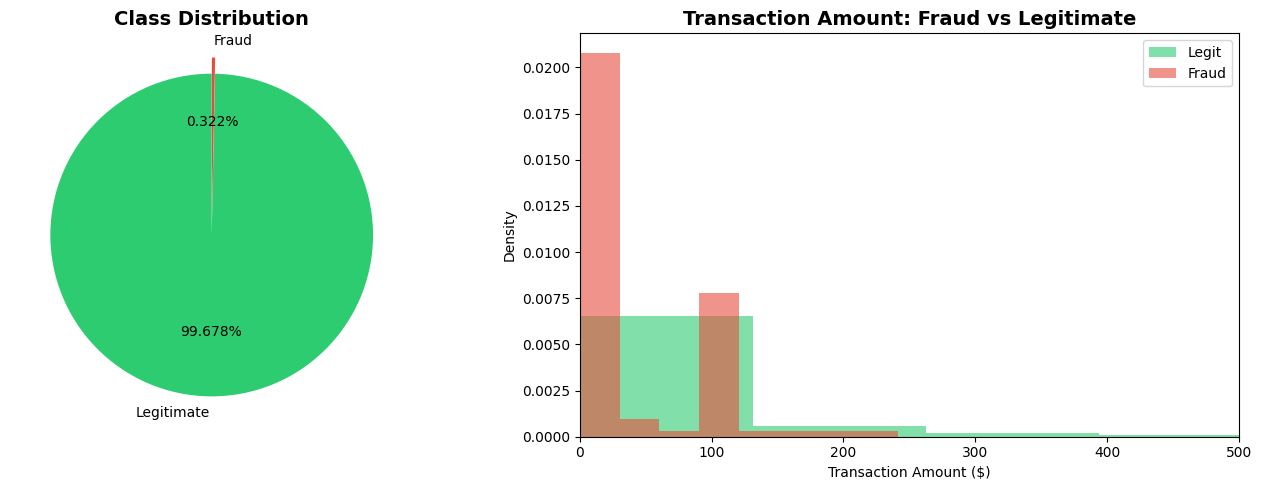

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Class imbalance pie
axes[0].pie(fraud_count, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Transaction Amount Distribution
axes[1].hist(df[df['Class'] == 0]['Amount'], bins=60, alpha=0.6, color='#2ecc71', label='Legit', density=True)
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=60, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Transaction Amount: Fraud vs Legitimate', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 500)
plt.tight_layout()
plt.savefig('eda_1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

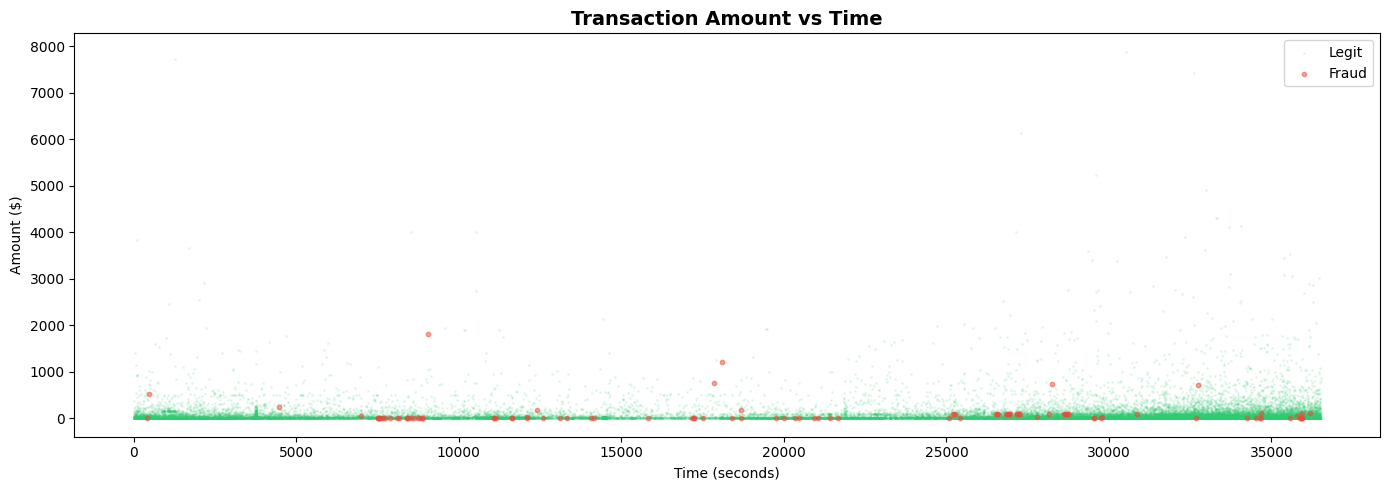

In [14]:
# Time analysis
fig, ax = plt.subplots(figsize=(14, 5))
df_legit = df[df['Class'] == 0]
df_fraud = df[df['Class'] == 1]
ax.scatter(df_legit['Time'], df_legit['Amount'], alpha=0.1, s=1, color='#2ecc71', label='Legit')
ax.scatter(df_fraud['Time'], df_fraud['Amount'], alpha=0.5, s=10, color='#e74c3c', label='Fraud')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amount ($)')
ax.set_title('Transaction Amount vs Time', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_2_time_vs_amount.png', dpi=150, bbox_inches='tight')
plt.show()

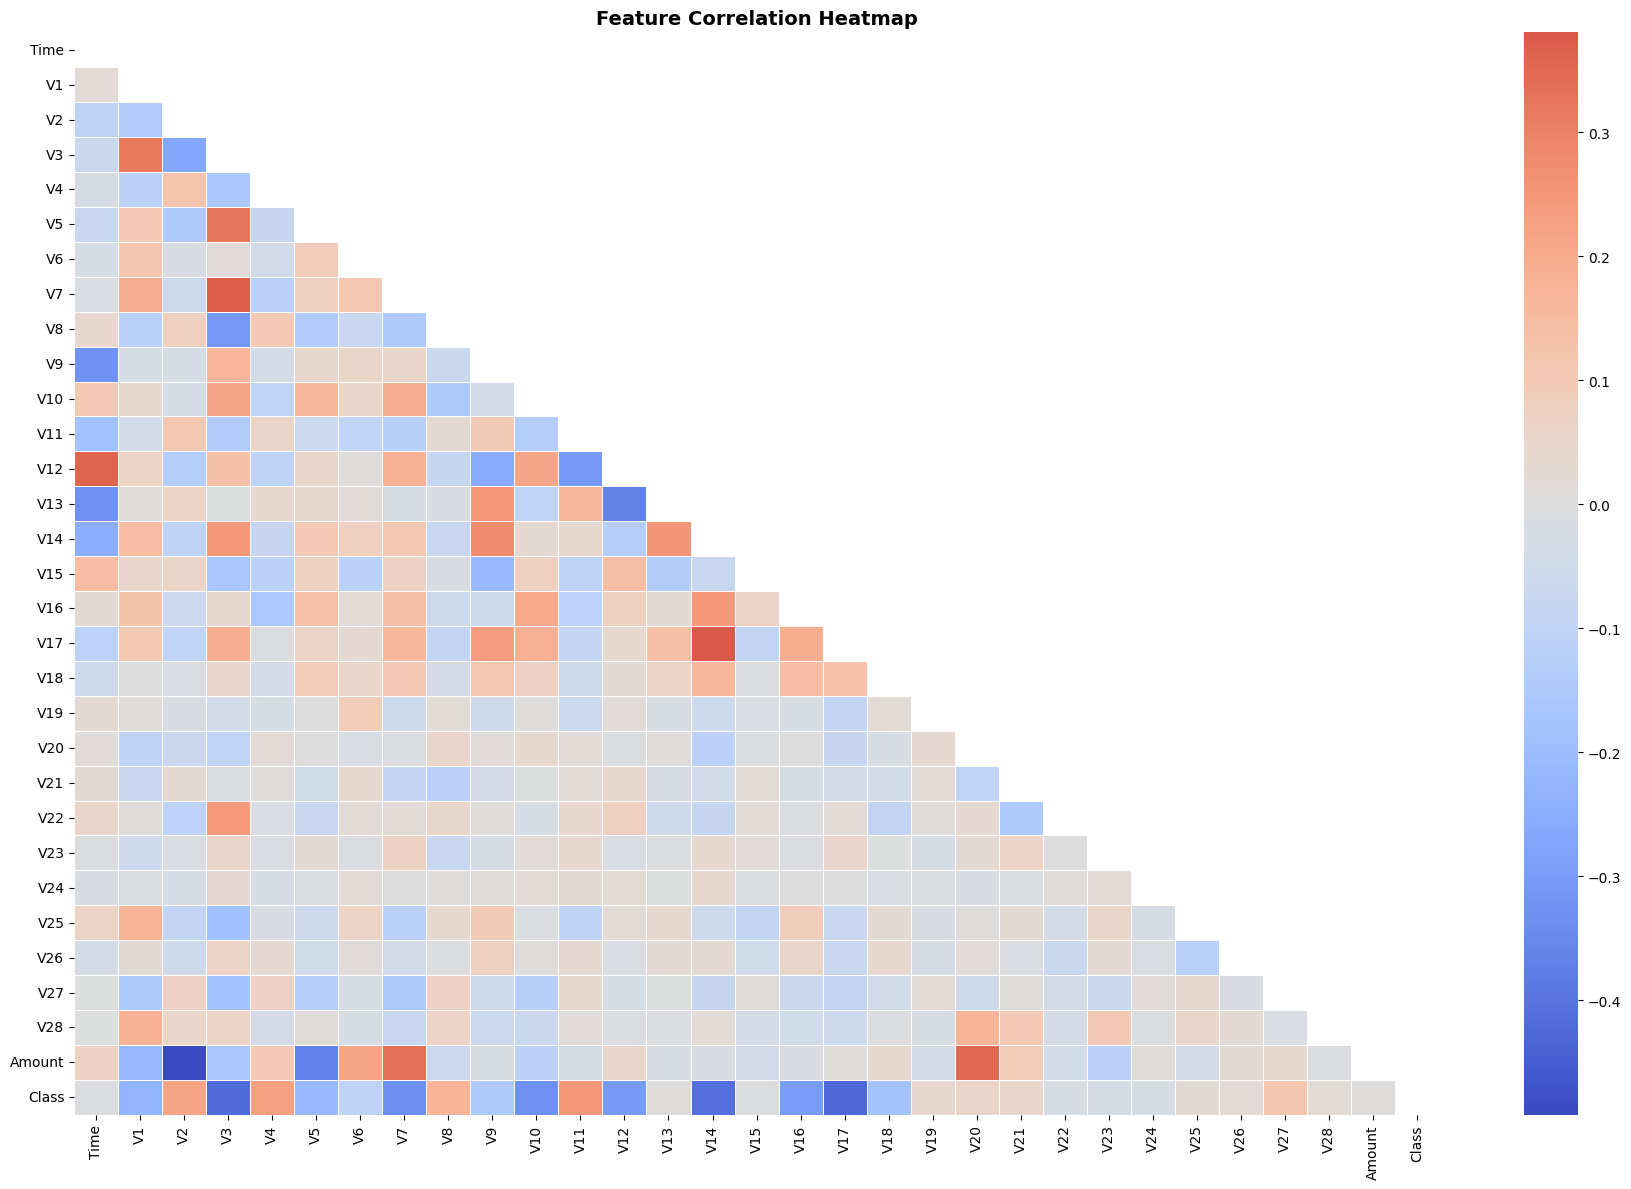

In [15]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, fmt='.2f', annot=False)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

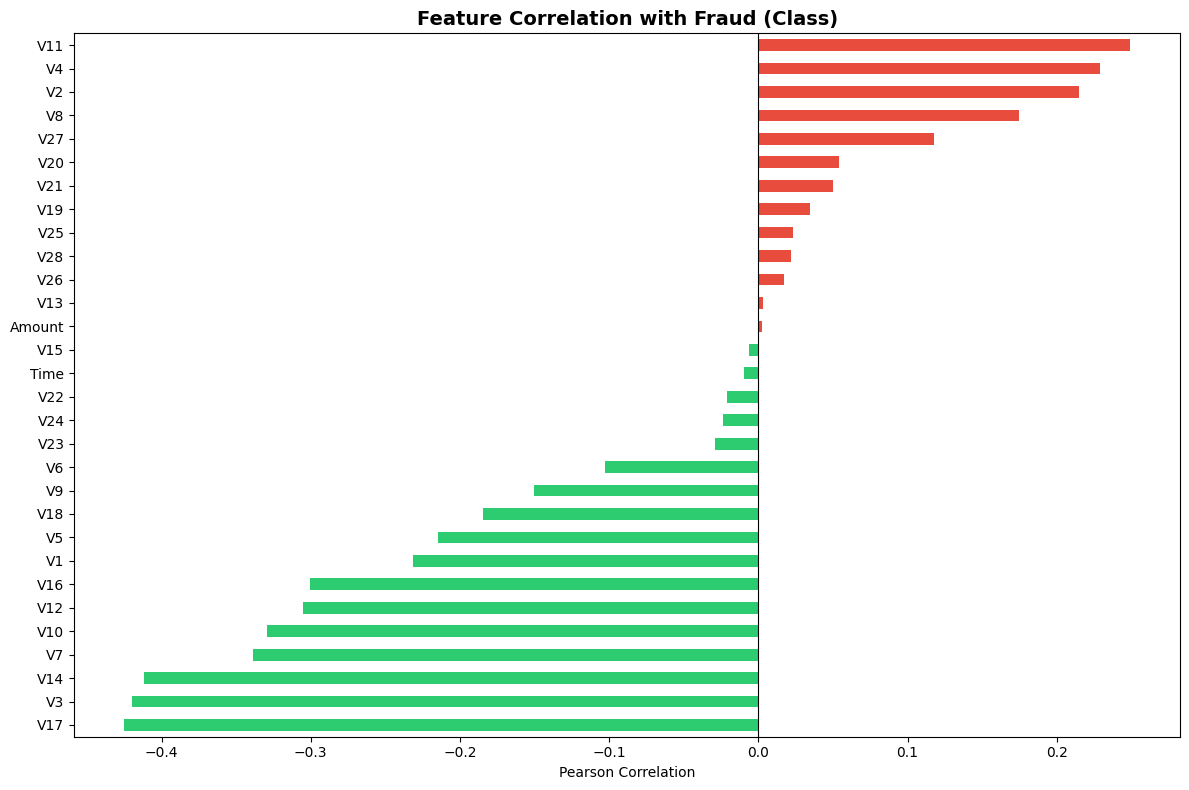

In [16]:
# Feature correlation with Class (bivariate)
corr_with_class = df.corr()['Class'].drop('Class').sort_values()
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr_with_class]
corr_with_class.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlation with Fraud (Class)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('eda_4_correlation_with_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df_fraud['Amount'].mean()

np.float64(91.23745098039213)

In [19]:
df_legit['Amount'].mean()

np.float64(81.28227177634082)

In [20]:
corr_with_class.abs().nlargest(5).index.tolist()

['V17', 'V3', 'V14', 'V7', 'V10']

In [21]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score, average_precision_score)

In [22]:
# scaling for Amount and Time
scaler = RobustScaler()
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time'] = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

In [25]:
df.dropna(subset=['Class'], inplace=True)
X = df.drop('Class', axis=1)
y = df['Class']
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [27]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE resampling:")
print(f"  Shape: {X_train_res.shape}")
print(f"  Class dist: {pd.Series(y_train_res).value_counts().to_dict()}")


After SMOTE resampling:
  Shape: (37857, 30)
  Class dist: {0.0: 25238, 1.0: 12619}


In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

import joblib
import shap

In [30]:
# Scale all features
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train_res)
X_test_scaled = feature_scaler.transform(X_test)

# Save scaler for deployment
joblib.dump(feature_scaler, 'scaler.pkl')
print("Scaler saved to scaler.pkl")

Scaler saved to scaler.pkl


In [31]:
# Feature Engineering: interaction features
X_train_eng = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_eng = pd.DataFrame(X_test_scaled, columns=X.columns)


Top 20 features selected (by RF importance):
['V14', 'V17', 'V10', 'V4', 'V3', 'V12', 'V11', 'V16', 'V2', 'V7', 'V27', 'V21', 'scaled_Amount', 'V19', 'V9', 'V26', 'V6', 'V28', 'V5', 'V20']


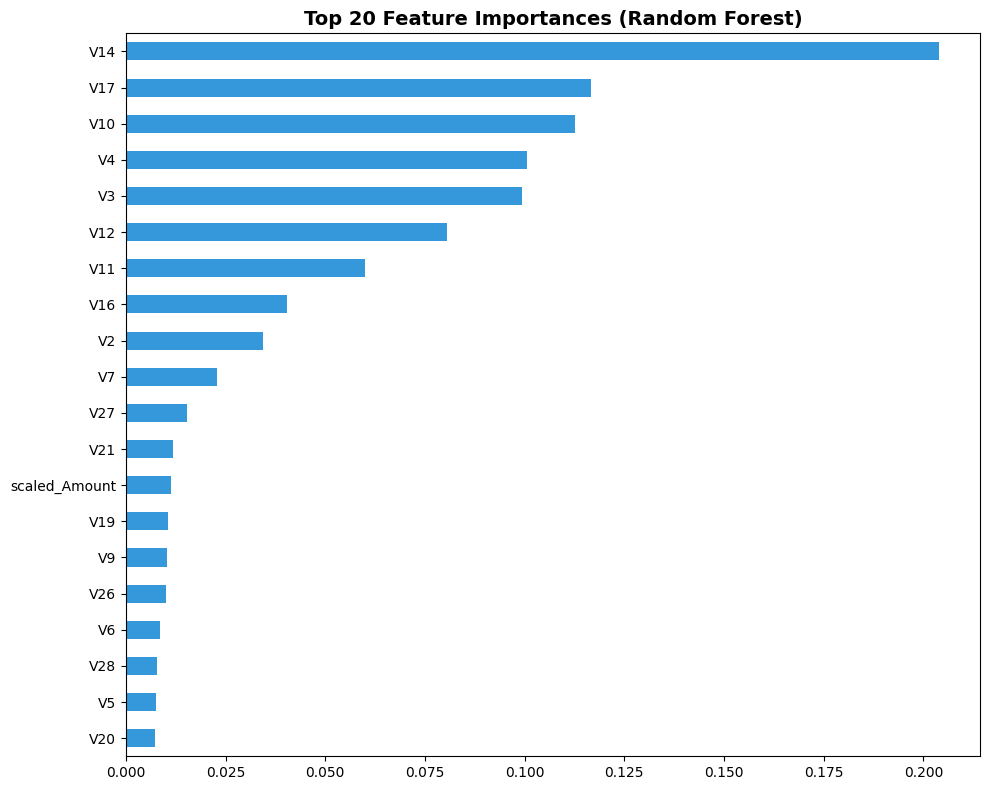

In [32]:
# Feature selection using Random Forest importances
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train_res)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
top_features = importances.nlargest(20).index.tolist()

print(f"\nTop 20 features selected (by RF importance):\n{top_features}")

fig, ax = plt.subplots(figsize=(10, 8))
importances.nlargest(20).sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Use top features for training
X_train_sel = pd.DataFrame(X_train_scaled, columns=X.columns)[top_features].values
X_test_sel = pd.DataFrame(X_test_scaled, columns=X.columns)[top_features].values

# Save feature list for deployment
joblib.dump(top_features, 'top_features.pkl')

['top_features.pkl']

## Model Building

In [34]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"\n{'─'*40}")
    print(f"  {model_name}")
    print(f"{'─'*40}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  PR-AUC    : {pr_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

    return {
        'name': model_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'y_prob': y_prob,
        'y_pred': y_pred
    }

results = {}

Logistic Regression

In [35]:
lr = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sel, y_train_res)
results['Logistic Regression'] = evaluate_model(lr, X_test_sel, y_test, "Logistic Regression")


────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────
  Precision : 0.1562
  Recall    : 1.0000
  F1-Score  : 0.2703
  ROC-AUC   : 0.9987
  PR-AUC    : 0.6158
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99      6310
       Fraud       0.16      1.00      0.27        20

    accuracy                           0.98      6330
   macro avg       0.58      0.99      0.63      6330
weighted avg       1.00      0.98      0.99      6330



Decision Tree

In [36]:
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, class_weight='balanced', random_state=42)
dt.fit(X_train_sel, y_train_res)
results['Decision Tree'] = evaluate_model(dt, X_test_sel, y_test, "Decision Tree")


────────────────────────────────────────
  Decision Tree
────────────────────────────────────────
  Precision : 0.5429
  Recall    : 0.9500
  F1-Score  : 0.6909
  ROC-AUC   : 0.9743
  PR-AUC    : 0.7222
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      6310
       Fraud       0.54      0.95      0.69        20

    accuracy                           1.00      6330
   macro avg       0.77      0.97      0.84      6330
weighted avg       1.00      1.00      1.00      6330



Random Forest

In [37]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_sel, y_train_res)
results['Random Forest'] = evaluate_model(rf, X_test_sel, y_test, "Random Forest")


────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  Precision : 0.8261
  Recall    : 0.9500
  F1-Score  : 0.8837
  ROC-AUC   : 1.0000
  PR-AUC    : 0.9892
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      6310
       Fraud       0.83      0.95      0.88        20

    accuracy                           1.00      6330
   macro avg       0.91      0.97      0.94      6330
weighted avg       1.00      1.00      1.00      6330



XGBoost

In [38]:
scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     scale_pos_weight=scale_pos_weight,
                     eval_metric='auc', random_state=42, use_label_encoder=False)
xgb.fit(X_train_sel, y_train_res,
        eval_set=[(X_test_sel, y_test)],
        verbose=False)
results['XGBoost'] = evaluate_model(xgb, X_test_sel, y_test, "XGBoost")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:43:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  Precision : 0.7600
  Recall    : 0.9500
  F1-Score  : 0.8444
  ROC-AUC   : 0.9999
  PR-AUC    : 0.9833
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      6310
       Fraud       0.76      0.95      0.84        20

    accuracy                           1.00      6330
   macro avg       0.88      0.97      0.92      6330
weighted avg       1.00      1.00      1.00      6330



# ANN MODEL

In [39]:
# ANN Architecture Design
def build_ann(input_dim, learning_rate=0.001, dropout_rate=0.3):
    model = Sequential([
        Dense(256, input_dim=input_dim, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        BatchNormalization(),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

In [40]:
ann_model = build_ann(X_train_sel.shape[1])
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,561 (197.50 KB)

 Trainable params: 49,601 (193.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [41]:
# Compute class weights for ANN
class_weights = {
    0: 1.0,
    1: (y_train_res == 0).sum() / (y_train_res == 1).sum()
}

callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = ann_model.fit(
    X_train_sel, y_train_res,
    epochs=100,
    batch_size=512,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9437 - auc: 0.9888 - loss: 0.5127 - precision: 0.8159 - recall: 0.9542 - val_accuracy: 0.8799 - val_auc: 0.0000e+00 - val_loss: 0.5824 - val_precision: 1.0000 - val_recall: 0.8799 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9889 - auc: 0.9983 - loss: 0.3211 - precision: 0.9669 - recall: 0.9820 - val_accuracy: 0.8891 - val_auc: 0.0000e+00 - val_loss: 0.4697 - val_precision: 1.0000 - val_recall: 0.8891 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9925 - auc: 0.9992 - loss: 0.2500 - precision: 0.9752 - recall: 0.9905 - val_accuracy: 0.8980 - val_auc: 0.0000e+00 - val_loss: 0.3670 - val_precision: 1.0000 - val_recall: 0.8980 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9948 - auc: 0.9994 - loss: 0.1978 - precision: 0.9818 - recall: 0.9945 - val_accuracy: 0.9410 - val_auc: 0.0000e+00 - val_l

In [42]:
# ANN Evaluation
y_prob_ann = ann_model.predict(X_test_sel).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

ann_metrics = {
    'name': 'ANN (Deep Learning)',
    'precision': precision_score(y_test, y_pred_ann),
    'recall': recall_score(y_test, y_pred_ann),
    'f1': f1_score(y_test, y_pred_ann),
    'roc_auc': roc_auc_score(y_test, y_prob_ann),
    'pr_auc': average_precision_score(y_test, y_prob_ann),
    'y_prob': y_prob_ann,
    'y_pred': y_pred_ann
}
results['ANN'] = ann_metrics

198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [43]:
print(f"\nANN Results:")
print(f"  Precision : {ann_metrics['precision']:.4f}")
print(f"  Recall    : {ann_metrics['recall']:.4f}")
print(f"  F1-Score  : {ann_metrics['f1']:.4f}")
print(f"  ROC-AUC   : {ann_metrics['roc_auc']:.4f}")
print(f"  PR-AUC    : {ann_metrics['pr_auc']:.4f}")


ANN Results:
  Precision : 0.5758
  Recall    : 0.9500
  F1-Score  : 0.7170
  ROC-AUC   : 0.9984
  PR-AUC    : 0.5895


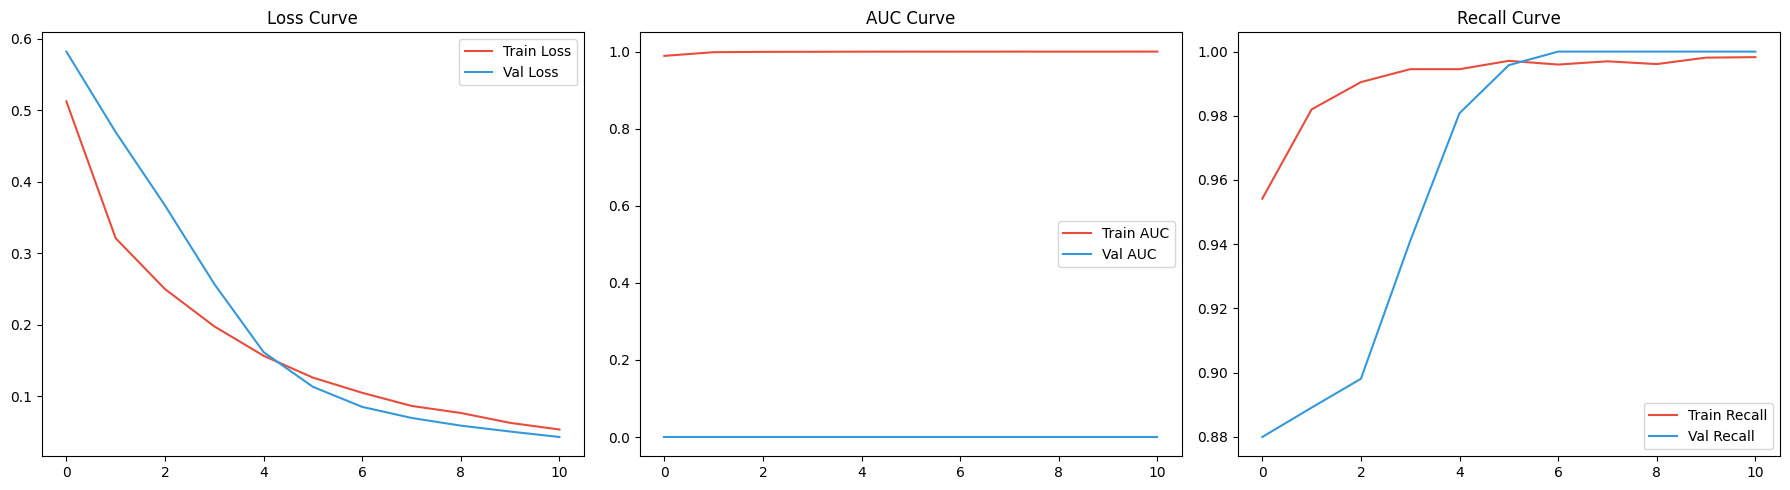

In [44]:
# Training history plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history.history['loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#3498db')
axes[0].set_title('Loss Curve')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC', color='#e74c3c')
axes[1].plot(history.history['val_auc'], label='Val AUC', color='#3498db')
axes[1].set_title('AUC Curve')
axes[1].legend()

axes[2].plot(history.history['recall'], label='Train Recall', color='#e74c3c')
axes[2].plot(history.history['val_recall'], label='Val Recall', color='#3498db')
axes[2].set_title('Recall Curve')
axes[2].legend()
plt.tight_layout()
plt.savefig('ann_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Save ANN
ann_model.save('ann_fraud_model.h5')
print("ANN model saved to ann_fraud_model.h5")

ANN model saved to ann_fraud_model.h5


MODEL EVALUATION

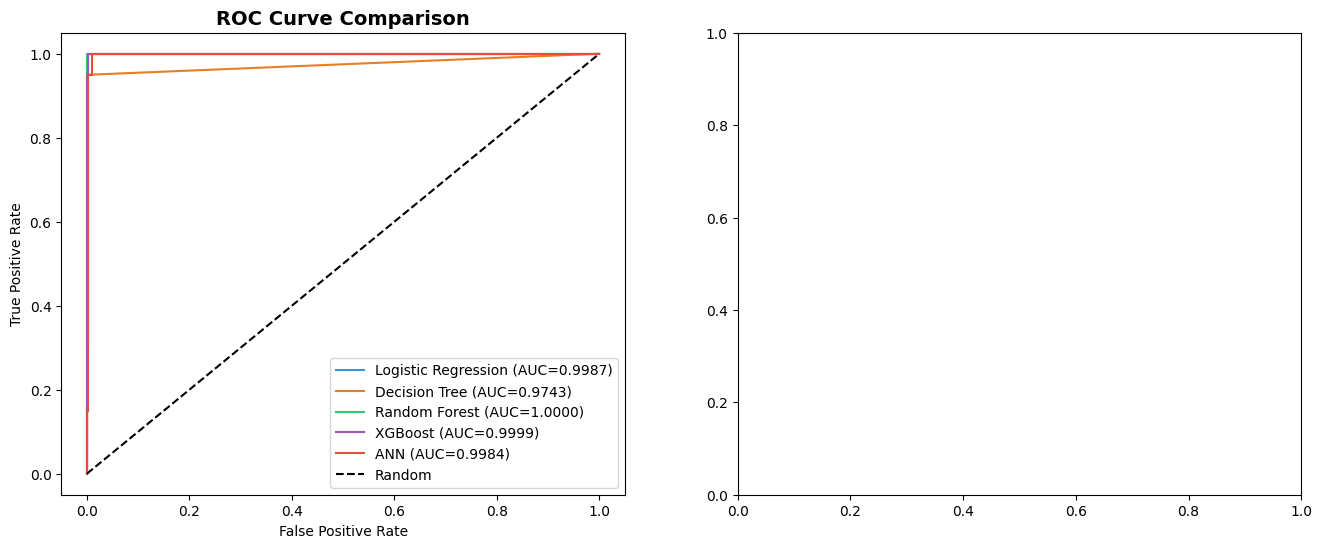

In [46]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for idx, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.4f})", color=colors[idx])

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')

In [47]:
# PR Curves
for idx, (name, res) in enumerate(results.items()):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(recall_vals, precision_vals, label=f"{name} (PR-AUC={res['pr_auc']:.4f})", color=colors[idx])

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.savefig('model_comparison_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

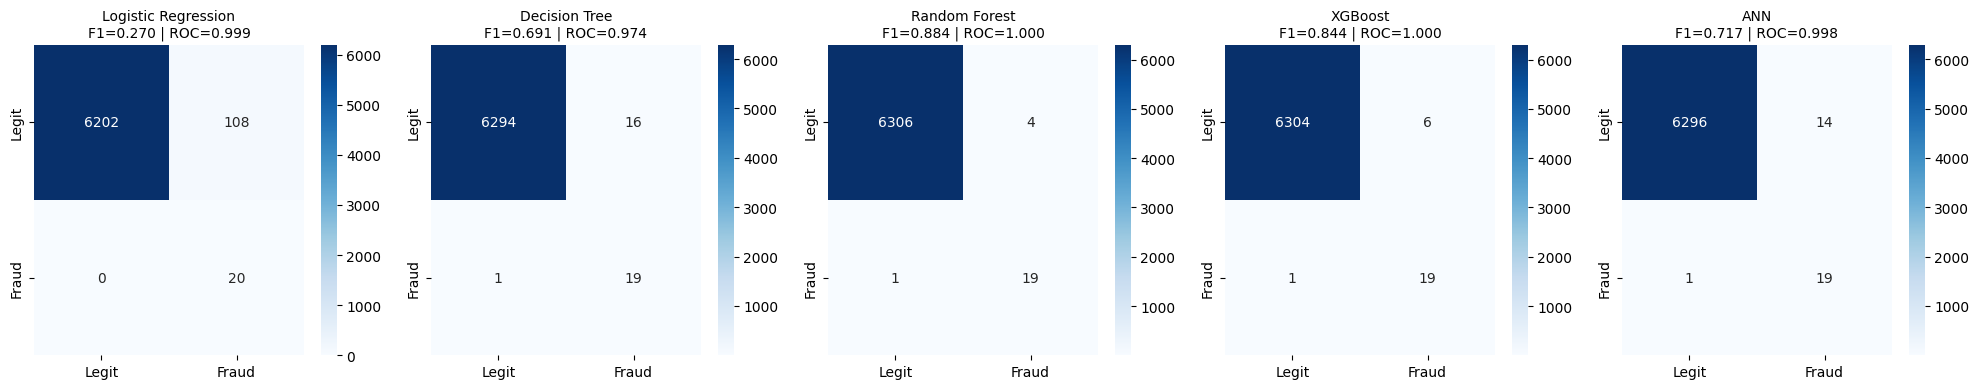

In [48]:
# Confusion Matrices
fig, axes = plt.subplots(1, len(results), figsize=(20, 4))
for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues',
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    axes[idx].set_title(f'{name}\nF1={res["f1"]:.3f} | ROC={res["roc_auc"]:.3f}', fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
summary_df = pd.DataFrame([{
    'Model': name,
    'Precision': f"{v['precision']:.4f}",
    'Recall': f"{v['recall']:.4f}",
    'F1-Score': f"{v['f1']:.4f}",
    'ROC-AUC': f"{v['roc_auc']:.4f}",
    'PR-AUC': f"{v['pr_auc']:.4f}"
} for name, v in results.items()])
print(summary_df.to_string(index=False))

              Model Precision Recall F1-Score ROC-AUC PR-AUC
Logistic Regression    0.1562 1.0000   0.2703  0.9987 0.6158
      Decision Tree    0.5429 0.9500   0.6909  0.9743 0.7222
      Random Forest    0.8261 0.9500   0.8837  1.0000 0.9892
            XGBoost    0.7600 0.9500   0.8444  0.9999 0.9833
                ANN    0.5758 0.9500   0.7170  0.9984 0.5895


HYPERPARAMETER TUNING & CROSS VALIDATION

In [50]:
# RandomizedSearchCV on XGBoost (best ML model)
param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

xgb_cv = XGBClassifier(random_state=42, eval_metric='auc', use_label_encoder=False,
                         scale_pos_weight=scale_pos_weight)

print("\nRunning RandomizedSearchCV on XGBoost (20 iterations)...")
random_search = RandomizedSearchCV(
    xgb_cv, param_dist, n_iter=20,
    scoring='roc_auc', cv=StratifiedKFold(n_splits=5),
    random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train_sel, y_train_res)
print(f"Best params: {random_search.best_params_}")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")

best_xgb = random_search.best_estimator_
best_xgb_results = evaluate_model(best_xgb, X_test_sel, y_test, "XGBoost (Tuned)")


Running RandomizedSearchCV on XGBoost (20 iterations)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:52:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV ROC-AUC: 1.0000

────────────────────────────────────────
  XGBoost (Tuned)
────────────────────────────────────────
  Precision : 0.7600
  Recall    : 0.9500
  F1-Score  : 0.8444
  ROC-AUC   : 0.9999
  PR-AUC    : 0.9823
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      6310
       Fraud       0.76      0.95      0.84        20

    accuracy                           1.00      6330
   macro avg       0.88      0.97      0.92      6330
weighted avg       1.00      1.00      1.00      6330



In [51]:
# K-Fold Cross Validation on best model
cv_scores = cross_val_score(best_xgb, X_train_sel, y_train_res,
                             cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='roc_auc', n_jobs=-1)
print(f"  CV ROC-AUC scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

  CV ROC-AUC scores: [0.999996   0.99988651 1.         0.99999984 0.99999992]
  Mean: 1.0000 ± 0.0000


OVERFITTING / UNDERFITTING ANALYSIS

In [52]:
# Training vs Validation performance comparison
models_to_check = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost (Tuned)': best_xgb
}

print("\nTrain vs Test ROC-AUC (check for overfitting):")
print(f"{'Model':<25} {'Train AUC':>12} {'Test AUC':>12} {'Gap':>10}")
print("-" * 62)
for name, model in models_to_check.items():
    train_auc = roc_auc_score(y_train_res, model.predict_proba(X_train_sel)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test_sel)[:, 1])
    gap = train_auc - test_auc
    status = "✅ Good" if gap < 0.02 else ("⚠️ Slight Overfit" if gap < 0.05 else "❌ Overfit")
    print(f"{name:<25} {train_auc:>12.4f} {test_auc:>12.4f} {gap:>10.4f}  {status}")


Train vs Test ROC-AUC (check for overfitting):
Model                        Train AUC     Test AUC        Gap
--------------------------------------------------------------
Logistic Regression             0.9979       0.9987    -0.0009  ✅ Good
Random Forest                   1.0000       1.0000     0.0000  ✅ Good
XGBoost (Tuned)                 1.0000       0.9999     0.0001  ✅ Good


In [53]:
# ANN train vs val loss analysis
print("\nANN Overfitting Analysis (from training history):")
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f"  Final Train Loss: {final_train_loss:.4f}")
print(f"  Final Val Loss:   {final_val_loss:.4f}")
if final_val_loss > final_train_loss * 1.3:
    print("  ⚠️ Possible overfitting. Consider increasing Dropout or L2.")
else:
    print("  ✅ No significant overfitting detected.")


ANN Overfitting Analysis (from training history):
  Final Train Loss: 0.0534
  Final Val Loss:   0.0429
  ✅ No significant overfitting detected.


In [54]:
# Save best model
joblib.dump(best_xgb, 'best_model_xgb.pkl')

['scaler.pkl']

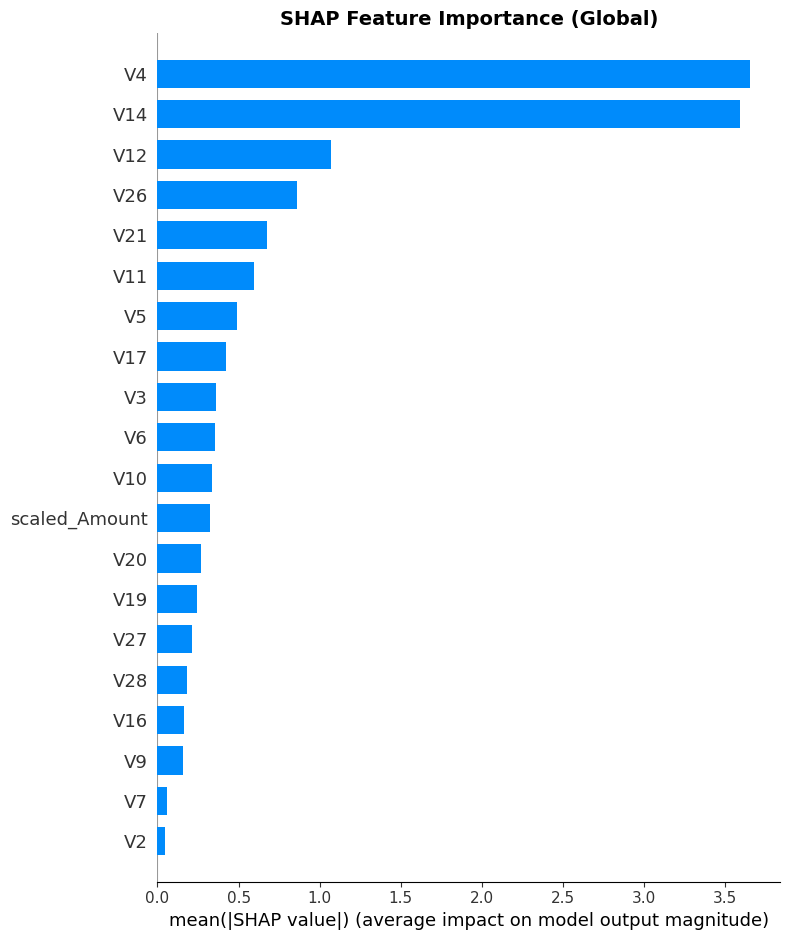

In [56]:
# Initialize SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_sel)

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test_sel[:500],
                  feature_names=top_features,
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()